# Quarterly analysis of attendee demographics for general admissions!

This uses the output from the query *General Admission Demographics*!

**HOW TO USE THIS JUPYTER NOTEBOOK:** highlight the cell by clicking on it. You should see a green or blue box surround it. Then hold the Shift key and press Enter. You should see the highlight box move on to the next cell, and it will print or plot whatever the code says to do.
Try it here. Click on the gray text box below to highlight the cell, then hold Shift and press Enter.

In [40]:
print("Hello world!")

Hello world!


If it says **Hello world!** to you below the gray cell, it worked!

Ok now, change the prefix below to be what you want, then press (Shift, Enter).

In [42]:
prefix = "fy25-q4"

## Import statements, classes, and methods. 
Run these (Shift, Enter) then keep going. They shouldn't spit anything out at you. If they do, tell Abbie.

In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme()
sns.set_style('whitegrid')
import matplotlib.pyplot as plt
import ipywidgets as widgets
import traitlets
from IPython.display import display
from tkinter import Tk, filedialog

In [27]:
class SelectFilesButton(widgets.Button):
    """A file widget that leverages tkinter.filedialog."""

    def __init__(self):
        super(SelectFilesButton, self).__init__()
        # Add the selected_files trait
        self.add_traits(files=traitlets.traitlets.List())
        # Create the button.
        self.description = "Select Files"
        self.icon = "square-o"
        self.style.button_color = "orange"
        # Set on click behavior.
        self.on_click(self.select_files)

    @staticmethod
    def select_files(b):
        """Generate instance of tkinter.filedialog.

        Parameters
        ----------
        b : obj:
            An instance of ipywidgets.widgets.Button 
        """
        # Create Tk root
        root = Tk()
        # Hide the main window
        root.withdraw()
        # Raise the root to the top of all windows.
        root.call('wm', 'attributes', '.', '-topmost', True)
        # List of selected fileswill be set to b.value
        b.files = filedialog.askopenfilename(multiple=True)

        b.description = "Files Selected"
        b.icon = "check-square-o"
        b.style.button_color = "lightgreen"

In [28]:
def clean_up_df(raw_df):
    """ 
    Cleans up data from the Altru query General Admission Demographics.
    """
    
    clean_df = pd.DataFrame(columns=('Registrant ID', 'Attended', 'Date', 'MSU affiliation', 'Race/Ethnicity', 'Gender'))
    clean_df['Registrant ID'] = raw_df['Registrant ID'].unique()

    for i in range(len(clean_df)):
        reg_idx = raw_df[ raw_df['Registrant ID'] == clean_df.loc[i,'Registrant ID']].index
        this_reg = raw_df.loc[reg_idx]
        try:
            fvi=reg_idx[0]
        except IndexError:
            print(i, clean_df.loc[i,'Registrant ID'], reg_idx)
        try:
            clean_df.loc[i, 'Attended'] = this_reg['Attended'][fvi]
        except KeyError:
                print("The data file has someone listed incorrectly as program admission when it should be daily admission. "\
                "Please open the excel file and scroll down to where there's a blank Registrant ID and blank Attended, "\
                "scroll over, and check that the program name is Daily Admission. If not, change the program to Daily Admission and save. "\
                "Then restart the kernel here and run again!")
        clean_df.loc[i, 'Date'] = pd.to_datetime(this_reg['Date added'][fvi])
        clean_df.loc[i, 'MSU affiliation'] = this_reg['Price type code'][fvi]
        
        re_idx = this_reg[ this_reg['Question'].str.contains("Race/Ethnicity")].index
        if len(re_idx) > 0:
            clean_df.loc[i, 'Race/Ethnicity'] = this_reg.loc[re_idx[0], 'Response']
        else:
            clean_df.loc[i, 'Race/Ethnicity'] = "Prefer not to specify"
            
        g_idx = this_reg[ this_reg['Question'].str.contains("Gender")].index
        if len(g_idx) > 0:
            clean_df.loc[i, 'Gender'] = this_reg.loc[g_idx[0], 'Response']
        else:
            clean_df.loc[i, 'Gender'] = "Prefer not to specify"
                                                                                    
    clean_df.sort_values(by="Date", inplace=True)
    clean_df.drop(columns=["Registrant ID"], inplace = True)
    return clean_df

In [29]:
# button1 = SelectFilesButton()
# button1  # This will display the button in the context of Jupyter Notebook

In [30]:
ga_xlsx_file = "./%s/%s_GA.xlsx" % (prefix, prefix)
df = pd.read_excel(ga_xlsx_file, engine='openpyxl')
display(df.head(6))

,Registrant ID,Quantity,Attended,Program category,Date added,Sales Order Item\Sales Order Item Ticket\Program Events\Start date,Name,Program name,Price type code,Question,Response,ZIP,QUERYRECID
0,NaN,2,NaN,General Admission,2025-04-03 16:53:26.603,NaT,Jeff Mills,Daily Admission,Non-MSU Affiliated,NaN,NaN,48823,51f91af9-2e60-4fb6-a882-5d9b16b68273
1,NaN,1,NaN,General Admission,2025-04-11 11:21:40.403,NaT,Shel Kimen,Daily Admission,Non-MSU Affiliated,NaN,NaN,NaN,c57b9694-f71c-4ae4-aab1-f3858b2ee066
2,NaN,1,NaN,General Admission,2025-04-24 16:22:55.677,NaT,Annabelle Knott,Daily Admission,MSU Student,NaN,NaN,NaN,855b20b4-54e5-41b6-a00f-a821f029e977
3,NaN,1,NaN,General Admission,2025-04-29 16:59:31.010,NaT,Abby Refior,Daily Admission,MSU Student,NaN,NaN,NaN,eabc6945-f792-49f2-98da-905a68b628f2
4,NaN,1,NaN,General Admission,2025-05-15 16:29:27.487,NaT,Courtney Theut,Daily Admission,Non-MSU Affiliated,NaN,NaN,48823,c34f0529-f538-413d-932e-ad8ca3b70b3d
5,NaN,2,NaN,General Admission,2025-06-07 16:18:17.293,NaT,PJ Smaza,Daily Admission,MSU Student,NaN,NaN,NaN,9993d8f7-e781-452e-86db-22b564018444


In [31]:
schools_idx = df[ df['Program name'].str.contains("School:")].index
df.drop(schools_idx, inplace = True)
msum_staff_idx = df[ df['Name'].str.contains("Denice Blair") | 
                     df['Name'].str.contains("Stephanie Palagyi") | 
                     df['Name'].str.contains("Abbie Stevens") | 
                     df['Name'].str.contains("Rachel Lewis") | 
                     df['Name'].str.contains("Sydney Urbaniak") | 
                     df['Name'].str.contains("Jane Moore")].index
df.drop(msum_staff_idx, inplace = True)
df.fillna({"Response": "Prefer not to specify", "Question": "Prefer not to specify"}, inplace = True)
#display(df.head(4))

In [32]:
dailies_idx = df[ df['Program name'].str.contains("Daily")].index
print(dailies_idx)
dailies = df.loc[dailies_idx]
dailies.fillna({"Attended": "Yes"}, inplace = True)
responses = np.repeat("Prefer not to specify", len(dailies))
dailies['Race/Ethnicity'] = responses
dailies['Gender'] = responses
dailies.rename(columns={"Price type code": "MSU affiliation"}, inplace = True)
dailies['Date'] = pd.to_datetime(dailies['Date added'])
dailies.drop(columns=["Name", "Registrant ID", "Quantity", "Program category", "Program name", 
                      "QUERYRECID", "Question", "Response", "Date added"], inplace=True)
display(dailies.head(6))

Index([0, 1, 2, 3, 4, 5, 6, 7, 459], dtype='int64')


,Attended,Sales Order Item\Sales Order Item Ticket\Program Events\Start date,MSU affiliation,ZIP,Race/Ethnicity,Gender,Date
0,Yes,NaT,Non-MSU Affiliated,48823,Prefer not to specify,Prefer not to specify,2025-04-03 16:53:26.603
1,Yes,NaT,Non-MSU Affiliated,NaN,Prefer not to specify,Prefer not to specify,2025-04-11 11:21:40.403
2,Yes,NaT,MSU Student,NaN,Prefer not to specify,Prefer not to specify,2025-04-24 16:22:55.677
3,Yes,NaT,MSU Student,NaN,Prefer not to specify,Prefer not to specify,2025-04-29 16:59:31.010
4,Yes,NaT,Non-MSU Affiliated,48823,Prefer not to specify,Prefer not to specify,2025-05-15 16:29:27.487
5,Yes,NaT,MSU Student,NaN,Prefer not to specify,Prefer not to specify,2025-06-07 16:18:17.293


In [33]:
normals = clean_up_df(df.drop(dailies_idx))
print(normals)

    Attended                        Date     MSU affiliation  \
0         No  2025-01-28 11:19:37.093000  Non-MSU Affiliated   
1         No  2025-02-20 15:28:13.880000  Non-MSU Affiliated   
2         No  2025-03-02 11:04:45.463000  Non-MSU Affiliated   
3         No  2025-03-02 11:04:45.463000  Non-MSU Affiliated   
4        Yes  2025-03-06 15:48:48.893000            MSU Alum   
..       ...                         ...                 ...   
416      Yes  2025-07-02 14:00:11.600000         MSU Student   
417      Yes  2025-07-02 14:03:06.963000         MSU Student   
418      Yes  2025-07-02 14:04:23.833000         MSU Student   
419      Yes  2025-07-02 14:07:42.310000  Non-MSU Affiliated   
420      Yes  2025-07-02 14:09:00.110000   MSU Faculty/Staff   

                Race/Ethnicity                 Gender  
0    Black or African American                    Man  
1                        White                  Woman  
2                        White                  Woman  
3      

In [34]:
ga_totals = pd.concat([dailies, normals])

In [35]:
attended_idx = ga_totals[ ga_totals['Attended'] == "Yes"].index
ga_attended = ga_totals.loc[attended_idx]
print("Number of people attended: %d" % len(ga_attended))

Number of people attended: 347


In [36]:
affil_cats = ['Student', 'Faculty/Staff', 'Alum', 'Parent/Family', 'Not MSU', 'N/A']
ga_attended['MSU affiliation'] = ga_attended['MSU affiliation'].replace("MSU Student", "Student")
ga_attended['MSU affiliation'] = ga_attended['MSU affiliation'].replace("MSU Faculty/Staff", "Faculty/Staff")
ga_attended['MSU affiliation'] = ga_attended['MSU affiliation'].replace("MSU Alum", "Alum")
ga_attended['MSU affiliation'] = ga_attended['MSU affiliation'].replace("MSU Parent/Family", "Parent/Family")
ga_attended['MSU affiliation'] = ga_attended['MSU affiliation'].replace("Non-MSU Affiliated", "Not MSU")
ga_attended['MSU affiliation'] = pd.Categorical(ga_attended['MSU affiliation'], categories=affil_cats, ordered=True)
print(ga_attended['MSU affiliation'].value_counts(dropna=False))

MSU affiliation
Not MSU          192
Student           49
Alum              45
Faculty/Staff     34
Parent/Family     27
N/A                0
Name: count, dtype: int64


In [37]:
print(ga_attended['Gender'].value_counts())

Gender
Prefer not to specify    265
Man                       43
Woman                     35
Non-binary                 2
Genderqueer                1
Two-spirit                 1
Name: count, dtype: int64


In [38]:
print(ga_attended['Race/Ethnicity'].value_counts())

Race/Ethnicity
Prefer not to specify                  265
White                                   61
Black or African American               10
Asian or Asian American                  6
Hispanic, Latino, Latina, or Latinx      2
Arab, Chaldean, or Arab American         1
American Indian or Alaska Native         1
Other                                    1
Name: count, dtype: int64


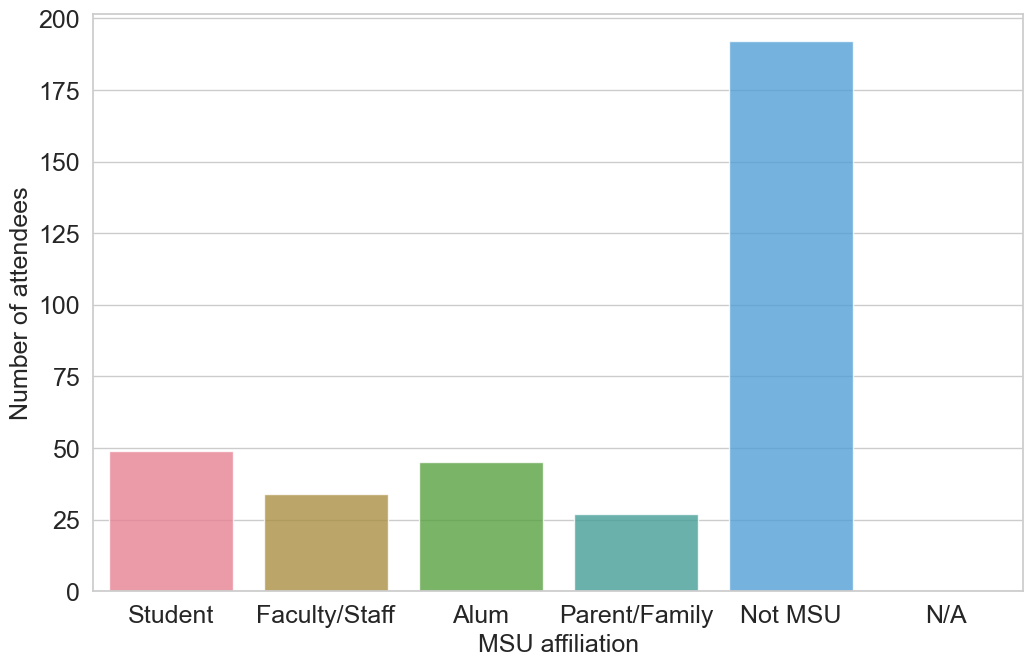

In [39]:
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(12,7.5))
sns.set_palette("husl")
fig = sns.countplot(data=ga_attended, x='MSU affiliation', hue='MSU affiliation', alpha=0.8, gap=0, legend=False, stat='count', dodge=False)
ax.set(xlabel="MSU affiliation", ylabel="Number of attendees")
ax.tick_params(axis='both', which='major', labelsize=18)
ax.xaxis.label.set_size(18)
ax.yaxis.label.set_size(18)
#ax.bar_label(ax.containers[0])
fig.figure.savefig("./%s/%s_ga_affil_bar.png" % prefix, bbox_inches='tight')
plt.show()

# Don't use the rest of this

In [15]:
ay2223_xlsx_file = "./AY22-23.xlsx"
ay2324_xlsx_file = "./AY23-24.xlsx"

ay22_23 = pd.read_excel(ay2223_xlsx_file, engine='openpyxl')
ay22_23.rename(columns={'Constituent\Last/Organization/Group/Household name': 'Last name', 
                        'Constituent\First name': 'First name', 
                        'Constituent\Lookup ID': 'Lookup ID'}, inplace=True)
print(ay22_23.info())
ay23_24 = pd.read_excel(ay2324_xlsx_file, engine='openpyxl')
ay23_24.rename(columns={'Constituent\Last/Organization/Group/Household name': 'Last name', 
                        'Constituent\First name': 'First name', 
                        'Constituent\Lookup ID': 'Lookup ID'}, inplace=True)
print(ay23_24.info())

<>:5: SyntaxWarning: invalid escape sequence '\L'
<>:6: SyntaxWarning: invalid escape sequence '\F'
<>:7: SyntaxWarning: invalid escape sequence '\L'
<>:10: SyntaxWarning: invalid escape sequence '\L'
<>:11: SyntaxWarning: invalid escape sequence '\F'
<>:12: SyntaxWarning: invalid escape sequence '\L'
<>:5: SyntaxWarning: invalid escape sequence '\L'
<>:6: SyntaxWarning: invalid escape sequence '\F'
<>:7: SyntaxWarning: invalid escape sequence '\L'
<>:10: SyntaxWarning: invalid escape sequence '\L'
<>:11: SyntaxWarning: invalid escape sequence '\F'
<>:12: SyntaxWarning: invalid escape sequence '\L'
/var/folders/2b/bxdw1yzn5_vb2kd7bdhn0z3c0000gr/T/ipykernel_6053/1723615046.py:5: SyntaxWarning: invalid escape sequence '\L'
  ay22_23.rename(columns={'Constituent\Last/Organization/Group/Household name': 'Last name',
/var/folders/2b/bxdw1yzn5_vb2kd7bdhn0z3c0000gr/T/ipykernel_6053/1723615046.py:6: SyntaxWarning: invalid escape sequence '\F'
  'Constituent\First name': 'First name',
/var/fold

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6824 entries, 0 to 6823
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Last name          6817 non-null   object        
 1   First name         6823 non-null   object        
 2   Lookup ID          6824 non-null   object        
 3   Transaction date   6824 non-null   datetime64[ns]
 4   Sales method type  6824 non-null   object        
dtypes: datetime64[ns](1), object(4)
memory usage: 266.7+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4266 entries, 0 to 4265
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Last name          4262 non-null   object        
 1   First name         4264 non-null   object        
 2   Lookup ID          4266 non-null   object        
 3   Transaction date   4266 non-null   datetime64[ns]
 4   Sa

In [16]:
ay22_23 = ay22_23.drop_duplicates() 
print(len(ay22_23))
ay23_24 = ay23_24.drop_duplicates()
print(len(ay23_24))

6651
3984


In [17]:
ay23_24['Lookup ID'].isin(ay22_23['Lookup ID'].unique().tolist())

0       False
1       False
2       False
3       False
4       False
        ...  
4260     True
4261     True
4263     True
4264     True
4265     True
Name: Lookup ID, Length: 3984, dtype: bool

In [18]:
repeats = ay23_24[ay23_24['Lookup ID'].isin(ay22_23['Lookup ID'].unique().tolist())]

In [19]:
len(repeats['Lookup ID'].unique())

655

In [20]:
fy24_xlsx_file = "./Attendees by Date FY24.xlsx"
fy24 = pd.read_excel(fy24_xlsx_file, engine='openpyxl')
fy24.rename(columns={'Last/Organization/Group/Household name': 'Last name'}, inplace=True)
print(fy24.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4074 entries, 0 to 4073
Data columns (total 4 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Lookup ID                              4074 non-null   object        
 1   Sales Orders\Reservation\Arrival date  258 non-null    datetime64[ns]
 2   Last name                              4074 non-null   object        
 3   First name                             4069 non-null   object        
dtypes: datetime64[ns](1), object(3)
memory usage: 127.4+ KB
None


In [21]:
reps = fy24.groupby(fy24['Lookup ID'].tolist(), as_index=False).size()


In [22]:
len(sum(np.where(reps['size'] > 1)))

184